# 通过逻辑斯蒂回归实现手写数字多分类[0~9]
## pandas加载digits.csv数据

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from loguru import logger
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [10]:
logger.add(
    "logs/digits_logistic.log",
    rotation="1 MB",
    encoding="utf-8",
    level="INFO"
)

2

In [11]:
raw_data = pd.read_csv("data/digits.csv")

logger.info("数据形状: {}", raw_data.shape)
display(raw_data.head())

2026-04-02 18:04:36.090 | INFO     | __main__:<module>:3 - 数据形状: (42000, 785)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
logger.info("列信息:\n{}", raw_data.info())
logger.info("缺失值统计:\n{}", raw_data.isnull().sum().head())
logger.info("标签分布:\n{}", raw_data["label"].value_counts().sort_index())

2026-04-02 18:04:36.143 | INFO     | __main__:<module>:1 - 列信息:
None
2026-04-02 18:04:36.154 | INFO     | __main__:<module>:2 - 缺失值统计:
label     0
pixel0    0
pixel1    0
pixel2    0
pixel3    0
dtype: int64
2026-04-02 18:04:36.155 | INFO     | __main__:<module>:3 - 标签分布:
label
0    4132
1    4684
2    4177
3    4351
4    4072
5    3795
6    4137
7    4401
8    4063
9    4188
Name: count, dtype: int64


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [13]:
X = raw_data.iloc[:, 1:]   # 假设第一列是 label 后面的像素列
y = raw_data["label"]

logger.info("X shape: {}", X.shape)
logger.info("y shape: {}", y.shape)

2026-04-02 18:04:36.159 | INFO     | __main__:<module>:4 - X shape: (42000, 784)
2026-04-02 18:04:36.159 | INFO     | __main__:<module>:5 - y shape: (42000,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

logger.info("X_train: {}", X_train.shape)
logger.info("X_test: {}", X_test.shape)
logger.info("y_train: {}", y_train.shape)
logger.info("y_test: {}", y_test.shape)

2026-04-02 18:04:36.940 | INFO     | __main__:<module>:8 - X_train: (33600, 784)
2026-04-02 18:04:36.941 | INFO     | __main__:<module>:9 - X_test: (8400, 784)
2026-04-02 18:04:36.941 | INFO     | __main__:<module>:10 - y_train: (33600,)
2026-04-02 18:04:36.941 | INFO     | __main__:<module>:11 - y_test: (8400,)


## 使用逻辑斯蒂回归建模

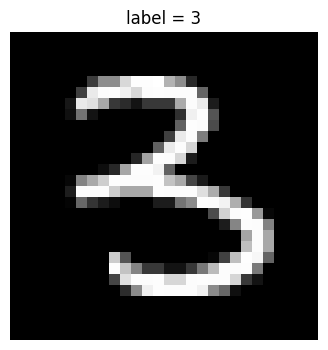

In [15]:
sample_idx = 1
plt.figure(figsize=(4, 4))
plt.imshow(X_train.iloc[sample_idx].values.reshape(28, 28), cmap="gray")
plt.title(f"label = {y_train.iloc[sample_idx]}")
plt.axis("off")
plt.show()

In [16]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=5000,
        solver="lbfgs",
        random_state=42
    ))
])

In [17]:
# 训练模型
pipeline.fit(X_train, y_train)

# 预测类别
y_pred = pipeline.predict(X_test)

# 预测概率
y_prob = pipeline.predict_proba(X_test)

logger.info("预测类别前10个: {}", y_pred[:10])
logger.info("预测概率前3个样本:\n{}", y_prob[:3])

2026-04-02 18:04:59.111 | INFO     | __main__:<module>:10 - 预测类别前10个: [1 8 6 8 5 7 6 7 7 7]
2026-04-02 18:04:59.112 | INFO     | __main__:<module>:11 - 预测概率前3个样本:
[[1.23277473e-15 9.99961991e-01 7.64669169e-06 9.75599460e-07
  1.01597294e-09 3.00818849e-07 1.07801239e-07 3.68328032e-07
  2.81511439e-05 4.57145690e-07]
 [2.16435167e-10 2.53876896e-06 7.57421669e-05 4.96698594e-03
  5.67143626e-10 1.07132560e-03 2.15202672e-08 2.25324476e-11
  9.93715858e-01 1.67526785e-04]
 [2.71987331e-14 5.08257863e-15 1.08770014e-14 4.57034877e-18
  9.59471360e-14 1.49121905e-08 9.99999985e-01 1.31357242e-17
  5.13032921e-18 5.82782238e-19]]


In [18]:
acc = accuracy_score(y_test, y_pred)
logger.info("测试集准确率: {:.6f}", acc)
print("accuracy =", acc)

print("\n分类报告：")
print(classification_report(y_test, y_pred))

2026-04-02 18:04:59.121 | INFO     | __main__:<module>:2 - 测试集准确率: 0.902500


accuracy = 0.9025

分类报告：
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       827
           1       0.93      0.97      0.95       937
           2       0.89      0.88      0.88       835
           3       0.89      0.87      0.88       870
           4       0.92      0.89      0.91       814
           5       0.84      0.86      0.85       759
           6       0.93      0.94      0.94       827
           7       0.93      0.93      0.93       880
           8       0.87      0.84      0.85       813
           9       0.87      0.89      0.88       838

    accuracy                           0.90      8400
   macro avg       0.90      0.90      0.90      8400
weighted avg       0.90      0.90      0.90      8400



## 混淆矩阵

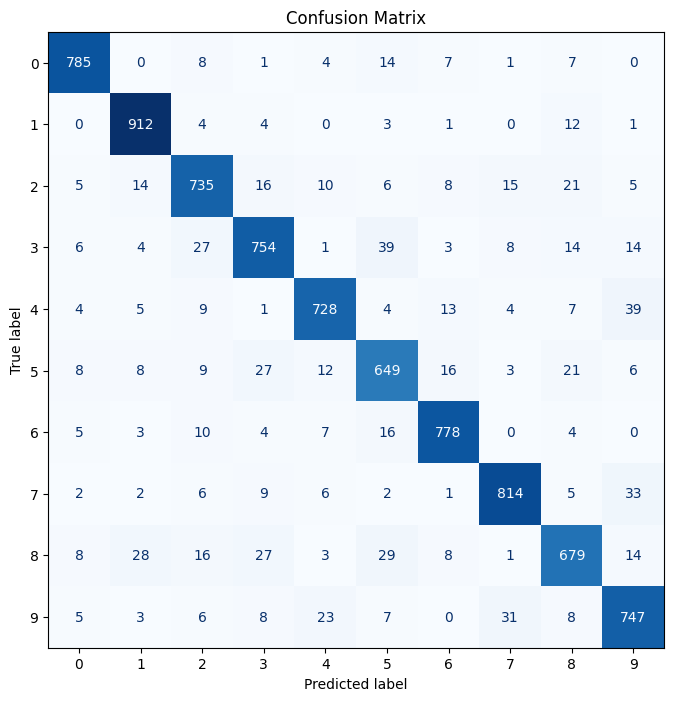

In [19]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix")
plt.show()

##  查看预测错误的样本

2026-04-02 18:04:59.235 | INFO     | __main__:<module>:2 - 预测错误样本数: 819


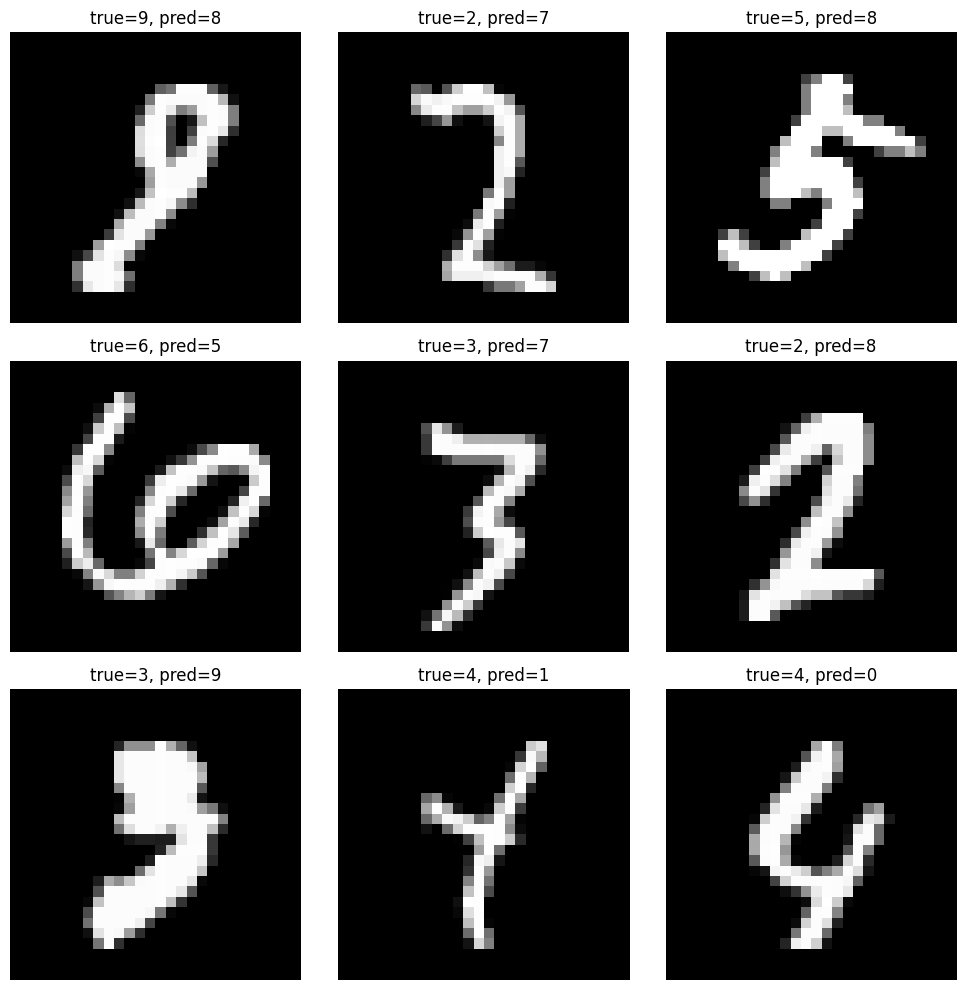

In [20]:
wrong_idx = np.where(y_pred != y_test.values)[0]
logger.info("预测错误样本数: {}", len(wrong_idx))

if len(wrong_idx) > 0:
    n_show = min(9, len(wrong_idx))
    plt.figure(figsize=(10, 10))
    for i, idx in enumerate(wrong_idx[:n_show]):
        plt.subplot(3, 3, i + 1)
        plt.imshow(X_test.iloc[idx].values.reshape(28, 28), cmap="gray")
        plt.title(f"true={y_test.iloc[idx]}, pred={y_pred[idx]}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

In [22]:
joblib.dump(pipeline, "models/digits_logistic_pipeline.pkl")
logger.info("模型已保存到 models/digits_logistic_pipeline.pkl")

2026-04-02 18:07:56.356 | INFO     | __main__:<module>:2 - 模型已保存到 models/digits_logistic_pipeline.pkl


## 手动计算概率

In [23]:
scaler = pipeline.named_steps["scaler"]
model = pipeline.named_steps["model"]

# 标准化后的测试集
X_test_scaled = scaler.transform(X_test)

# 取出参数
W = model.coef_         # shape: (10, 784)
b = model.intercept_    # shape: (10,)

print("W shape:", W.shape)
print("b shape:", b.shape)

W shape: (10, 784)
b shape: (10,)


In [24]:
z = X_test_scaled @ W.T + b   # shape: (n_samples, 10)

def softmax_stable(z):
    z = np.asarray(z)
    z_max = np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z - z_max)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

manual_prob = softmax_stable(z)

In [25]:
sklearn_prob = pipeline.predict_proba(X_test)

print("手动计算概率前3行：")
print(manual_prob[:3])

print("\nsklearn predict_proba 前3行：")
print(sklearn_prob[:3])

print("\n两者最大绝对误差：", np.max(np.abs(manual_prob - sklearn_prob)))

手动计算概率前3行：
[[1.23277473e-15 9.99961991e-01 7.64669169e-06 9.75599460e-07
  1.01597294e-09 3.00818849e-07 1.07801239e-07 3.68328032e-07
  2.81511439e-05 4.57145690e-07]
 [2.16435167e-10 2.53876896e-06 7.57421669e-05 4.96698594e-03
  5.67143626e-10 1.07132560e-03 2.15202672e-08 2.25324476e-11
  9.93715858e-01 1.67526785e-04]
 [2.71987331e-14 5.08257863e-15 1.08770014e-14 4.57034877e-18
  9.59471360e-14 1.49121905e-08 9.99999985e-01 1.31357242e-17
  5.13032921e-18 5.82782238e-19]]

sklearn predict_proba 前3行：
[[1.23277473e-15 9.99961991e-01 7.64669169e-06 9.75599460e-07
  1.01597294e-09 3.00818849e-07 1.07801239e-07 3.68328032e-07
  2.81511439e-05 4.57145690e-07]
 [2.16435167e-10 2.53876896e-06 7.57421669e-05 4.96698594e-03
  5.67143626e-10 1.07132560e-03 2.15202672e-08 2.25324476e-11
  9.93715858e-01 1.67526785e-04]
 [2.71987331e-14 5.08257863e-15 1.08770014e-14 4.57034877e-18
  9.59471360e-14 1.49121905e-08 9.99999985e-01 1.31357242e-17
  5.13032921e-18 5.82782238e-19]]

两者最大绝对误差： 0.0


## 查看某个样本的类别概率

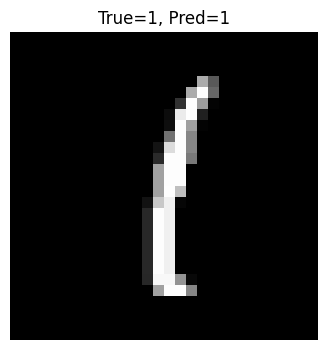

,class,probability
1,1,9.999620e-01
8,8,2.815114e-05
2,2,7.646692e-06
3,3,9.755995e-07
9,9,4.571457e-07
7,7,3.683280e-07
5,5,3.008188e-07
6,6,1.078012e-07
4,4,1.015973e-09
0,0,1.232775e-15


In [26]:
sample_id = 0
plt.figure(figsize=(4, 4))
plt.imshow(X_test.iloc[sample_id].values.reshape(28, 28), cmap="gray")
plt.title(f"True={y_test.iloc[sample_id]}, Pred={y_pred[sample_id]}")
plt.axis("off")
plt.show()

prob_df = pd.DataFrame({
    "class": np.arange(10),
    "probability": y_prob[sample_id]
}).sort_values("probability", ascending=False)

display(prob_df)

## 查看模型参数规模

In [27]:
logger.info("coef_ shape: {}", model.coef_.shape)
logger.info("intercept_ shape: {}", model.intercept_.shape)

print("coef_ shape:", model.coef_.shape)
print("intercept_ shape:", model.intercept_.shape)

2026-04-02 18:08:28.969 | INFO     | __main__:<module>:1 - coef_ shape: (10, 784)
2026-04-02 18:08:28.970 | INFO     | __main__:<module>:2 - intercept_ shape: (10,)


coef_ shape: (10, 784)
intercept_ shape: (10,)


## 调参

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__C": [0.01, 0.1, 1, 10]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("best params:", grid.best_params_)
print("best score:", grid.best_score_)

best params: {'model__C': 0.01}
best score: 0.9194642857142856


In [29]:
best_model = grid.best_estimator_
import os
os.makedirs("models", exist_ok=True)
joblib.dump(best_model, "models/best_digits_logistic.pkl")

['models/best_digits_logistic.pkl']